In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
import torch

/data_hdd/nauczanie/biofizyka_2026/ERNIE-RNA/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## RNA representations

In [2]:
with open("data/test_seqs.txt", "r") as f:
    test_seqs = [line.strip() for line in f]
print(f"Loaded {len(test_seqs)} test sequences of lengths: {[len(seq) for seq in test_seqs]}")

Loaded 2 test sequences of lengths: [124, 75]


In [4]:
results_dir = Path("results/ernie_rna_representations/test_seqs")
print("Files in results directory:")
for file in results_dir.glob("*"):
    print(f"  {file.name}")

Files in results directory:
  cls_embedding.npy
  all_embedding.npy
  attnmap.npy


In [5]:
all_embedding = np.load(results_dir / "all_embedding.npy")
print(f"All embedding shape: {all_embedding.shape}")

All embedding shape: (2, 12, 126, 768)


In [6]:
cls_embedding = np.load(results_dir / "cls_embedding.npy")
print(f"CLS embedding shape: {cls_embedding.shape}")

CLS embedding shape: (2, 12, 768)


In [ ]:
attention_map = np.load(results_dir / "attnmap.npy")
print(f"Attention map shape: {attention_map.shape} (num sequences, num layers * num heads, seq length, seq length)")

Attention map shape: (2, 156, 126, 126) (num sequences, num heads, seq length, seq length)


### Plot attention

Text(0, 0.5, 'Query Position')

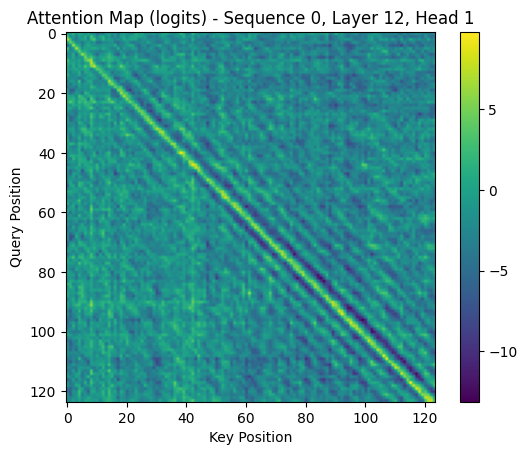

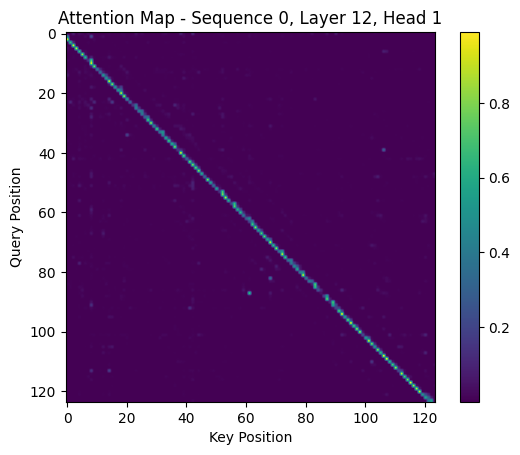

In [36]:
sequence_index = 0
layer_index = 12 # 0-12
head_index = 1 # 0-11
head_and_layer_index = layer_index * 12 + head_index
# 
crop_cls_eos = True

if crop_cls_eos:
    attention = attention_map[sequence_index][head_and_layer_index][1:-1, 1:-1]  # Remove CLS and EOS tokens
else:
    attention = attention_map[sequence_index][head_and_layer_index]

plt.figure()
plt.imshow(attention, cmap="viridis")
plt.colorbar()
plt.title(f"Attention Map (logits) - Sequence {sequence_index}, Layer {layer_index}, Head {head_index}")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.figure()
plt.imshow(softmax(attention, axis=-1), cmap="viridis")
plt.colorbar()
plt.title(f"Attention Map - Sequence {sequence_index}, Layer {layer_index}, Head {head_index}")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

In [25]:
def average_attention(logits, apply_apc=True):
    """
    Averages attention logits across heads.
    
    Args:
        logits (np.ndarray): Raw pre-softmax attention logits. 
                               Expected shape: (..., heads, seq_len, seq_len)
        apply_apc (bool): Whether to apply Average Product Correction (APC) to the symmetrized matrix.
    Returns:
        np.ndarray: The APC-corrected, symmetrized contact probability matrix.
    """
    # 1. Softmax along keys (last dimension)
    attn = softmax(logits, axis=-1)
    print(attn.min(), attn.max(), attn.mean())  # Debug: Check the range and mean of the attention values after softmax
    
    # 2. Average across heads
    A = attn.mean(axis=-3)
    
    # 3. Symmetrize
    A_sym = (A + A.transpose(-1, -2)) / 2
    
    # 4. Average Product Correction (APC)
    # APC = A_sym - (row_sums * col_sums) / total_sum
    if apply_apc:
        row_sum = A_sym.sum(axis=-1, keepdims=True)
        col_sum = A_sym.sum(axis=-2, keepdims=True)
        total_sum = A_sym.sum(axis=(-1, -2), keepdims=True)

        A_apc = A_sym - (row_sum * col_sum) / total_sum
    else:
        A_apc = A_sym
    
    # Zero out the diagonal (bases don't pair with themselves)
    diag_mask = np.eye(A_apc.shape[-1], dtype=bool)
    A_apc[diag_mask] = 0.0
    
    return A_apc

5.246509193323121e-18 0.999973387999796 0.008064516129032254
5.246509193323121e-18 0.999973387999796 0.008064516129032254


Text(0, 0.5, 'Query Position')

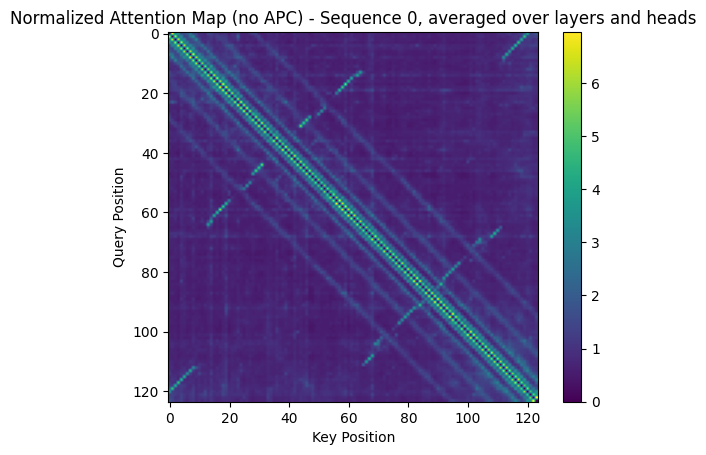

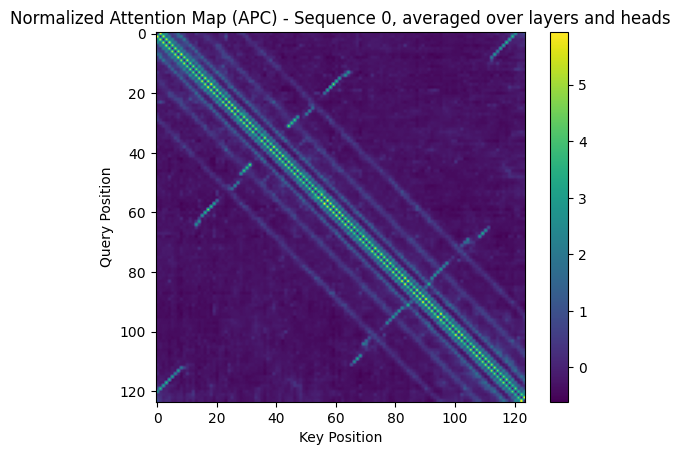

In [37]:
sequence_index = 0

plt.figure()
normalized_attention = average_attention(attention_map[sequence_index][:,1:-1,1:-1], apply_apc=False)  # Average over layers and heads, [:,1:-1,1:-1] cuts out the CLS and EOS tokens
normalized_attention *= normalized_attention.shape[-1]  # Scale by sequence length for better visualization
plt.imshow(normalized_attention, cmap="viridis")
plt.colorbar()
plt.title(f"Normalized Attention Map (no APC) - Sequence {sequence_index}, averaged over layers and heads")
plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.figure()
normalized_attention = average_attention(attention_map[sequence_index][:,1:-1,1:-1], apply_apc=True)  # Average over layers and heads, [:,1:-1,1:-1] cuts out the CLS and EOS tokens
normalized_attention *= normalized_attention.shape[-1]  # Scale by sequence length for better visualization
plt.imshow(normalized_attention, cmap="viridis")
plt.colorbar()
plt.title(f"Normalized Attention Map (APC) - Sequence {sequence_index}, averaged over layers and heads")
plt.xlabel("Key Position")
plt.ylabel("Query Position")